# Установка программ и скачивание файлов

## Скачивание собранного генома T. oleivorans Barents из своего репозитория

Создала токен: settings -> developer settings -> personal access tokens -> tokens (classic) -> generate new token

Скачиваю файл scaffolds.fasta

In [56]:
from getpass import getpass

token = getpass('GitHub token: ')
URL = f"https://raw.githubusercontent.com/ir-ir-ir/HSE_Bioinformatics/refs/heads/main/bioinf_hw1/data/scaffolds.fasta"

!wget --header="Authorization: token {token}" "{URL}"

GitHub token: ··········
--2025-10-27 21:04:06--  https://raw.githubusercontent.com/ir-ir-ir/HSE_Bioinformatics/refs/heads/main/bioinf_hw1/data/scaffolds.fasta
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3957133 (3.8M) [text/plain]
Saving to: ‘scaffolds.fasta’

scaffolds.fasta     100%[===================>]   3.77M  --.-KB/s    in 0.07s   

2025-10-27 21:04:07 (53.0 MB/s) - ‘scaffolds.fasta’ saved [3957133/3957133]



## Установка GeneMark

Скачиваю GeneMark и ключ здесь:

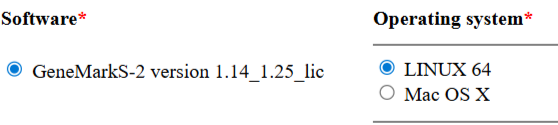

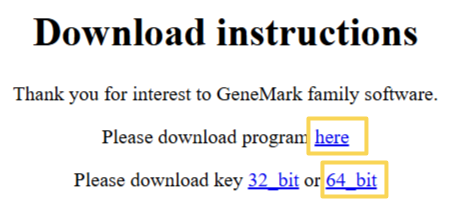

In [62]:
# загружаю файлы
from google.colab import files
uploaded = files.upload()

Saving gms2_linux_64.tar.gz to gms2_linux_64.tar.gz


In [63]:
uploaded = files.upload()

Saving gm_key_64.gz to gm_key_64.gz


In [64]:
!gzip -d gm_key_64.gz # распаковываю ключ (-d - распаковать файл)
!tar -xzvf gms2_linux_64.tar.gz # распаковываю программу (-x-извлечь файлы,-z-распаковать gzip,-v-показать процесс,-f-указать файл архива)
!cp -v gm_key_64 ~/.gmhmmp2_key # копирую ключ в ~/.gmhmmp2_key

gms2_linux_64/
gms2_linux_64/biogem
gms2_linux_64/mgm_4.mod
gms2_linux_64/LICENSE
gms2_linux_64/mgm_11.mod
gms2_linux_64/compp
gms2_linux_64/INSTALL
gms2_linux_64/gmhmmp2
gms2_linux_64/gms2.pl
gms2_linux_64/README_GMS2.txt
gms2_linux_64/mgm_25.mod
gms2_linux_64/mgm_15.mod
'gm_key_64' -> '/root/.gmhmmp2_key'


## Установка E-utilities (для скачивания последовательностей с NCBI)

In [65]:
!apt install -y ncbi-entrez-direct

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ncbi-entrez-direct is already the newest version (14.6.20210224+dfsg-5ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


## Скачивание аннотации генома, последовательностей всех генов ДНК, последовательностей белков организма T. oleivorans MIL-1


In [66]:
#efetch - программа для скачивания из NCBI
#-db - указывает базу данных
#-id HF680312 - ID генома
#-format - формат вывода (gb - GeneBank, gene_fasta - гены в формате fasta, fasta_cds_aa - белки в формате fasta )
#> - перенаправить вывод в файл

!efetch -db nuccore -id HF680312 -format gb  >  T_oleivorans_MIL_1.gbk # аннотация генома
!efetch -db nuccore -id HF680312 -format gene_fasta  >  T_oleivorans_MIL_1.genes.fasta # последовательности генов
!efetch -db nuccore -id HF680312 -format fasta_cds_aa  >  T_oleivorans_MIL_1.proteins.fasta # последовательности белков

## Установка BLAST

In [ ]:
!apt install ncbi-blast+

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  ncbi-data
The following NEW packages will be installed:
  ncbi-blast+ ncbi-data
0 upgraded, 2 newly installed, 0 to remove and 38 not upgraded.
Need to get 15.8 MB of archives.
After this operation, 71.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-data all 6.1.20170106+dfsg1-9 [3,519 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-blast+ amd64 2.12.0+ds-3build1 [12.3 MB]
Fetched 15.8 MB in 2s (9,424 kB/s)
Selecting previously unselected package ncbi-data.
(Reading database ... 127768 files and directories currently installed.)
Preparing to unpack .../ncbi-data_6.1.20170106+dfsg1-9_all.deb ...
Unpacking ncbi-data (6.1.20170106+dfsg1-9) ...
Selecting previously unselected package ncbi-blast+.
Preparing to unpack .../ncbi-blast+_2.12.0+ds-3build1_amd64.deb 

## Скачивание базы данных белков SwissProt

In [67]:
!wget https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/complete/uniprot_sprot.fasta.gz
!gzip -d uniprot_sprot.fasta.gz # распаковка

--2025-10-27 21:08:17--  https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/complete/uniprot_sprot.fasta.gz
Resolving ftp.uniprot.org (ftp.uniprot.org)... 128.175.240.195
Connecting to ftp.uniprot.org (ftp.uniprot.org)|128.175.240.195|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 93100075 (89M) [application/x-gzip]
Saving to: ‘uniprot_sprot.fasta.gz’

uniprot_sprot.fasta 100%[===================>]  88.79M  83.0MB/s    in 1.1s    

2025-10-27 21:08:18 (83.0 MB/s) - ‘uniprot_sprot.fasta.gz’ saved [93100075/93100075]



## Установка seqkit

In [74]:
!wget https://github.com/shenwei356/seqkit/releases/download/v2.1.0/seqkit_linux_amd64.tar.gz # скачивание
!tar -xzvf seqkit_linux_amd64.tar.gz # разархивирование
!chmod a+x seqkit # изменение прав доступа: a+x - добавить права на выполнение для всех пользователей

--2025-10-27 21:11:42--  https://github.com/shenwei356/seqkit/releases/download/v2.1.0/seqkit_linux_amd64.tar.gz
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/52715040/ea4018ec-70e8-40ac-a4aa-3326b04e07c4?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-10-27T21%3A57%3A44Z&rscd=attachment%3B+filename%3Dseqkit_linux_amd64.tar.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-10-27T20%3A56%3A56Z&ske=2025-10-27T21%3A57%3A44Z&sks=b&skv=2018-11-09&sig=4289GQTx5fOvHofBGv6xekgcXtG53TNXnDHvQgOf%2FBU%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2MTU5OTgwMiwibmJmIjoxNzYxNTk5NTAyLCJwYXRoIjoicmVsZWFzZWFzc2V

# Нахожу гены GeneMark’ом

In [68]:
# использую в GeneMark команду gms2.pl для предсказания белок-кодирующих генов
# --seq - входной файл с геномом
# --genome-type - вид организма
# --fnn - создает файл, в котором будут сохранены последовательности генов
# --faa - создает файл, в котором будут сохранены аминокислотные последовательности белков

!./gms2_linux_64/gms2.pl  --seq scaffolds.fasta  --genome-type bacteria  --fnn genes.fasta  --faa proteins.fasta

Координаты предсказанных генов сохранены в файле gms2.lst

# Определяю функции белков бактерии через сравнение с белками из T.oleivorans MIL-1

Создаю БД

In [69]:
# -dbtype - тип базы данных (prot - белки)
# -in - fasta-файл с аминокислотными последовательностями, на основе которых делается база
# -out - префикс созданных файлов

!makeblastdb  -dbtype prot  -in T_oleivorans_MIL_1.proteins.fasta -out T_oleivorans_MIL_1.proteins



Building a new DB, current time: 10/27/2025 21:09:49
New DB name:   /content/T_oleivorans_MIL_1.proteins
New DB title:  T_oleivorans_MIL_1.proteins.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 3666 sequences in 0.0878541 seconds.




Сравниваю белки T. oleivorans Barents с белками T.oleivorans MIL-1

In [70]:
# -query - файл c белок-кодирующими генами T. oleivorans Barents (предсказывала GeneMark-ом)
# -db - база данных для поиска похожих белков
# -evalue - пороговое значение evalue
# -outfmt - формат вывода, 6 - табличный формат
# > - перенаправление вывода
!blastp -query proteins.fasta -db T_oleivorans_MIL_1.proteins -evalue 1e-10 -outfmt 6 > scaffolds.hits_from_MIL_1.txt

Фильтрую по identity - минимум 90%

In [71]:
# identity находится в третьем столбце
!awk '$3 >= 90' scaffolds.hits_from_MIL_1.txt > scaffolds.hits_from_MIL_1_filtered.txt

# Использую базу SwissProt

Извлекаю список ID белков, для которых уже определена функция

In [72]:
# cut -f 1 - извлекает первую колонку из файла
# sort -n - отсортировать как числа
# uniq - удаление дубликатов
# > - перенаправление вывода в файл
!cut -f 1 scaffolds.hits_from_MIL_1_filtered.txt | sort -n | uniq > proteins.with_hits_from_MIL_1.txt

 Из исходного FASTA-файла извлекаю только те белки, которых нет в списке из предыдущего шага

In [75]:
# grep - поиск шаблонов в последовательностях
# --invert-match - вернуть не совпадающие последовательности
# -f - указывает файл с шаблонами для поиска
# proteins.fasta - входной файл
# -o proteins.without_MIL_1.fasta - выходной файл
!./seqkit grep --invert-match -f proteins.with_hits_from_MIL_1.txt proteins.fasta -o proteins.without_MIL_1.fasta

[INFO] 3181 patterns loaded from file


Проверяю количество

In [76]:
# grep '>' - находит все строки с заголовками fasta (начинаются с >)
# wc -l - подсчет строк
!grep '>' proteins.fasta | wc -l
!wc -l proteins.with_hits_from_MIL_1.txt
!grep '>' proteins.without_MIL_1.fasta | wc -l

3607
3181 proteins.with_hits_from_MIL_1.txt
426


3181 +426 = 3607

Создаю БД

In [77]:
# аналогично предыдущему шагу, где создавалась БД
!makeblastdb -dbtype prot -in uniprot_sprot.fasta -out uniprot_sprot



Building a new DB, current time: 10/27/2025 21:11:58
New DB name:   /content/uniprot_sprot
New DB title:  uniprot_sprot.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 573661 sequences in 11.4483 seconds.




Определяю функции с помощью SwissProt

In [78]:
# -query - входной файл
# -db - указать базу данных
# -evalue - порог evalue
# -outfmt 6 - табличный формат
!blastp -query proteins.without_MIL_1.fasta -db uniprot_sprot -evalue 1e-10 -outfmt 6 > scaffolds.hits_from_SwissProt.txt

Аналогичным образом выполняю фильтрацию по identity

In [79]:
!awk '$3 >= 30' scaffolds.hits_from_SwissProt.txt > scaffolds.hits_from_SwissProt_identity30.txt

Аналогичным образом подсчитываю количество аннотированных белков

In [80]:
!cut -f 1 scaffolds.hits_from_SwissProt_identity30.txt | sort | uniq | wc -l

108


# Нахожу тРНК с помощью tRNAscan

In [81]:
!apt install trnascan-se # установка

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
trnascan-se is already the newest version (2.0.9+ds-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [82]:
# -B - геном принадлежит бактерии
# -o - выходной файл
!tRNAscan-SE -B -o tRNA.txt scaffolds.fasta


tRNAscan-SE v.2.0.9 (July 2021) - scan sequences for transfer RNAs
Copyright (C) 2020 Patricia Chan and Todd Lowe
                   University of California Santa Cruz
Freely distributed under the GNU General Public License (GPLv3)

------------------------------------------------------------
Sequence file(s) to search:        scaffolds.fasta
Search Mode:                       Bacterial
Results written to:                tRNA.txt
Output format:                     Tabular
Searching with:                    Infernal First Pass->Infernal
Isotype-specific model scan:       Yes
Covariance model:                  /usr/share/trnascan-se/models/TRNAinf-bact.cm
                                   /usr/share/trnascan-se/models/TRNAinf-bact-SeC.cm
Infernal first pass cutoff score:  10

Temporary directory:               /tmp
------------------------------------------------------------

Status: Phase I: Searching for tRNAs with HMM-enabled Infernal
Status: Phase II: Infernal verification of cand

# Преобразование в формат GeneBank

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 35.9 MB/s eta 0:00:00


In [83]:
from Bio import SeqIO, SeqFeature
from Bio.SeqFeature import FeatureLocation, BeforePosition, AfterPosition, ExactPosition
import re

Парсинг аннотаций

In [84]:
# T_oleivorans_MIL_1.proteins.fasta данные
MIL_1 = {}

for rec in SeqIO.parse("T_oleivorans_MIL_1.proteins.fasta", "fasta"):
    # Создаю словарь аннотаций используя генератор словаря
    # Регулярное выражение ищет все пары [ключ=значение] в описании
    ann = {k: v.strip() for k, v in re.findall(r'\[([^=]+)=([^\]]+)\]', rec.description)}
    if 'protein' in ann: ann['protein'] = ann['protein'].replace('  ', ' ') # Обрабатываю пробелы
    MIL_1[rec.id] = ann # Сохраняю в словарь по ID последовательности

# Проверка (вывожу первый элемент)
first_key, first_value = next(iter(MIL_1.items()))
print(first_key)
for key, value in first_value.items():
    print(f"{key}: {value}")
print("\n")

# uniprot_sprot.fasta данные
SwissProt = {}
for record in SeqIO.parse("uniprot_sprot.fasta", "fasta"):
    desc = record.description.replace(record.id, '').strip()  # Удаляю ID из описания
    info = {}
    # Извлекаю основное описание (все до OS=)
    os_pos = desc.find(' OS=')
    if os_pos != -1: info['description'] = desc[:os_pos].strip()
    # Парсинг дополнительных полей
    fields = ['OS', 'OX', 'GN', 'PE', 'SV']
    for field in fields:
        # Для OS использую расширенный паттерн (с пробелами), для остальных - базовый
        pattern = r'OS=([^=]+?)(?=\s+[A-Z]{2}=|$)' if field == 'OS' else fr'{field}=([^\s]+)'
        match = re.search(pattern, desc)
        if match: info[field] = match.group(1).strip()

    SwissProt[record.id] = info  # Сохраняю по ID записи

# Проверка
first_id, first_data = next(iter(SwissProt.items()))
print(first_id)
for k, v in first_data.items():
    print(f"{k}: {v}")
print("\n")

lcl|HF680312.1_prot_CCU70450.1_1
gene: dnaA
locus_tag: TOL_0001
db_xref: EnsemblGenomes-Gn:TOL_0001,EnsemblGenomes-Tr:CCU70450,GOA:M5DL16,InterPro:IPR001957,InterPro:IPR003593,InterPro:IPR010921,InterPro:IPR013159,InterPro:IPR013317,InterPro:IPR018312,InterPro:IPR020591,InterPro:IPR024633,InterPro:IPR027417,UniProtKB/TrEMBL:M5DL16
protein: chromosomal replication initiator protein
protein_id: CCU70450.1
location: 35..1624
gbkey: CDS


sp|Q6GZX4|001R_FRG3G
description: Putative transcription factor 001R
OS: Frog virus 3 (isolate Goorha)
OX: 654924
GN: FV3-001R
PE: 4
SV: 1




In [85]:
#/content/gms2.lst
gms2_data = {}
current_scaffold = None

with open('/content/gms2.lst', 'r') as f:
    for line in f:
        line = line.strip()

        # Пропускаю комментарии и пустые строки
        if not line or line.startswith('#'):
            continue

        # Обрабатываю строку с SequenceID
        if line.startswith('SequenceID:'):
            current_scaffold = line.split(':')[1].strip()
            gms2_data[current_scaffold] = []
            continue

        # Обрабатываю строки с генами
        if current_scaffold and line[0].isdigit():
            parts = line.split()
            if len(parts) >= 5:
                # Обрабатываю случай с < >
                start_str = parts[2].replace('<', '').replace('>', '')
                end_str = parts[3].replace('<', '').replace('>', '')

                gene_data = {
                    'gene_id': int(parts[0]),
                    'strand': 1 if parts[1] == '+' else -1,
                    'start': int(start_str),
                    'end': int(end_str),
                    'length': int(parts[4]),
                    'type': parts[5] if len(parts) > 5 else 'native',
                    'rbs': parts[6] if len(parts) > 6 else None,
                    'partial_start': '<' in parts[2],
                    'partial_end': '>' in parts[3]
                }
                gms2_data[current_scaffold].append(gene_data)

# Проверка
if gms2_data:
    first_scaffold = next(iter(gms2_data))
    print(f"Scaffold: {first_scaffold}")
    if gms2_data[first_scaffold]:
        first_gene = gms2_data[first_scaffold][0]
        strand_str = 'forward' if first_gene['strand'] == 1 else 'reverse'
        partial_info = " (partial start)" if first_gene['partial_start'] else ""
        print(f"  First gene {first_gene['gene_id']}: {first_gene['start']}-{first_gene['end']} ({strand_str}){partial_info}")
        print(f"  Length: {first_gene['length']} bp, Type: {first_gene['type']}")
        if first_gene.get('rbs'):
            print(f"  RBS: {first_gene['rbs']}")

Scaffold: scaffold1_cov231
  First gene 1: 3-98 (forward) (partial start)
  Length: 96 bp, Type: native


Парсинг результатов blast

In [86]:
# scaffolds.hits_from_MIL_1_filtered.txt
# Создаю словарь для хранения генов и множество для отслеживания обработанных ID
hits_from_MIL_1 = {}
processed = set()

with open("/content/scaffolds.hits_from_MIL_1_filtered.txt") as f:
    for l in f:
        seq_id, id = l.strip().split('\t')[:2] # Разделяю строку на колонки и беру первые два значения
        if seq_id in processed: continue  # Пропускаю строку если этот ID уже обработан
        if id in MIL_1:
            # Объединяю данные из MIL_1 с дополнительной информацией
            hits_from_MIL_1[seq_id] = MIL_1[id] | {'target': id, 'origin': 'MIL_1'}
            processed.add(seq_id)

first_id, first_data = next(iter(hits_from_MIL_1.items()))
print(first_id)
for k, v in first_data.items():
    print(f"{k}: {v}")
print("\n")

2
locus_tag: TOL_3256
db_xref: EnsemblGenomes-Gn:TOL_3256,EnsemblGenomes-Tr:CCU73646,InterPro:IPR013130,UniProtKB/TrEMBL:M5DUU5
protein: hypothetical protein
protein_id: CCU73646.1
location: complement(3429575..3430228)
gbkey: CDS
target: lcl|HF680312.1_prot_CCU73646.1_3197
origin: MIL_1




In [87]:
#scaffolds.hits_from_SwissProt_identity30.txt
# Обрабатываю SwissProt и добавляю к MIL_1 данным
swissprot_hits = {}
seen = set()

with open("/content/scaffolds.hits_from_SwissProt_identity30.txt", 'r') as file:
    for l in file:
        seq_id, id = l.strip().split('\t')[:2] # Разделяю строку на колонки и беру первые два значения
        if seq_id in seen: continue  # Пропускаю строку если этот ID уже обработан
        if id in SwissProt:
            # Объединяю данные из SwissProt с дополнительной информацией
            swissprot_hits[seq_id] = SwissProt[id] | {'target': id, 'origin': 'SwissProt'}
            seen.add(seq_id)

# Проверка
first_id, first_data = next(iter(swissprot_hits.items()))
print(first_id)
for k, v in first_data.items():
    print(f"{k}: {v}")
print("\n")

# Добавляю SwissProt данные к MIL_1
MIL_1.update(swissprot_hits)

211
description: Putative transposase InsO for insertion sequence element IS911B
OS: Escherichia coli (strain K12)
OX: 83333
GN: insO2
PE: 5
SV: 1
target: sp|Q47718|INSO2_ECOLI
origin: SwissProt




Парсинг результатов tRNAscan

In [88]:
#  Парсит файл с данными о tRNA и возвращает структурированные данные
def parse_tRNA_file(file_path):
    tRNA_records = {}

    with open(file_path, 'r') as f:
        # Пропускаю заголовочные строки
        for _ in range(3):
            next(f)
        for line_num, line in enumerate(f, start=4):
            if line.strip():
                process_tRNA_line(line, line_num, tRNA_records)

    return tRNA_records

# Обрабатываю одну строку с информацией о tRNA
def process_tRNA_line(line, line_num, records_dict):
    fields = re.split(r'\s+', line.strip())

    if len(fields) < 9:
        return  # Пропускаю некорректные строки

    scaffold = fields[0]
    scaffold_id = extract_scaffold_id(scaffold)
    trna_id = int(fields[1])

    # Создаю запись
    record = {
        'position': (fields[2], fields[3]),  # start, end
        'amino_acid': fields[4],
        'anticodon': fields[5],
        'intron_coords': (fields[6], fields[7]),
        'cove_score': float(fields[8]),
        'annotation': fields[9] if len(fields) > 9 else None
    }

    # Сохраняю в словарь
    if scaffold_id not in records_dict:
        records_dict[scaffold_id] = {}
    records_dict[scaffold_id][trna_id] = record

# Извлекаю числовой ID из названия скаффолда
def extract_scaffold_id(scaffold_name):
    match = re.search(r'scaffold(\d+)', scaffold_name)
    return match.group(1) if match else scaffold_name


file_path = "/content/tRNA.txt"
tRNA_data = parse_tRNA_file(file_path)

first_scaffold = next(iter(tRNA_data))
first_trna_id = next(iter(tRNA_data[first_scaffold]))
info = tRNA_data[first_scaffold][first_trna_id]
print(f"Scaffold {first_scaffold}, tRNA {first_trna_id}:")
print(f"  {info['amino_acid']}({info['anticodon']}) at {info['position'][0]}-{info['position'][1]}")
print(f"  Score: {info['cove_score']}, Intron: {info['intron_coords'][0]}-{info['intron_coords'][1]}")

Scaffold 1, tRNA 1:
  Arg(CCG) at 210579-210655
  Score: 77.8, Intron: 0-0


Для конвертации в формат GeneBank

In [89]:
def add_tRNA_to_scaffold(scaffold_record, scaffold_id):
    # Проверяю, есть ли tRNA для этого скаффолда
    if str(scaffold_id) not in tRNA_data:
        return

    for tRNA_id, info in tRNA_data[str(scaffold_id)].items():
        # Создаю location для tRNA
        begin, end = int(info["position"][0]), int(info["position"][1])
        location = FeatureLocation(min(begin, end) - 1, max(begin, end),
                                 strand=1 if begin < end else -1)

        # Создаю features и добавляю к записи
        tRNA_feature, gene_feature = create_tRNA_features(tRNA_id, location, info, begin, end)
        scaffold_record.features.extend([gene_feature, tRNA_feature])

def create_tRNA_features(tRNA_id, location, info, begin, end):
    # Базовые данные для features
    gene_name = f"tRNA-{info['amino_acid']}({info['anticodon']})"
    locus_tag = f"TOLB_tRNA_{int(tRNA_id):05d}"

    # Основные qualifiers для tRNA
    tRNA_qualifiers = {
        "gene": [gene_name],
        "locus_tag": [locus_tag],
        "product": [f"tRNA-{info['amino_acid']}"],
        "anticodon": [f"(pos:{begin}..{end},aa:{info['amino_acid']},seq:{info['anticodon']})"],
        "inference": ["profile:tRNAscan-SE:2.0.9"],
        "note": [f"Score: {info['cove_score']}"]
    }

    # Добавляю информацию об интроне если он есть
    intron_start, intron_end = info["intron_coords"]
    if intron_start != "0" or intron_end != "0":
        tRNA_qualifiers["note"].append(f"Intron: {intron_start}-{intron_end}")

    # Создаю features
    tRNA_feature = SeqFeature(location=location, type="tRNA", qualifiers=tRNA_qualifiers)
    gene_feature = SeqFeature(location=location, type="gene",
                            qualifiers={"gene": [gene_name], "locus_tag": [locus_tag]})

    return tRNA_feature, gene_feature

# Сортировка
def arrange_features(feature_list):
    # Приоритет типов features для сортировки
    priority = {'source': 0, 'gene': 1, 'CDS': 2, 'tRNA': 3}

    return sorted(feature_list,
                  key=lambda f: (int(f.location.start), int(f.location.end),
                               priority.get(f.type, 999)))

In [90]:
def add_CDS_to_scaffold(scaffold_record, scaffold_id):
    # Проверяю, есть ли предсказания генов для этого скаффолда
    scaffold_name = scaffold_record.id
    if scaffold_name not in gms2_data:
        return

    # Для каждого предсказанного гена создаю CDS feature
    for gene_info in gms2_data[scaffold_name]:
        # location
        location = FeatureLocation(
            gene_info['start'] - 1,
            gene_info['end'],
            strand=gene_info['strand']
        )

        # Информация из hits_from_MIL_1, если есть
        extra_info = {}
        if scaffold_name in hits_from_MIL_1:
            extra_info = hits_from_MIL_1[scaffold_name]

        # features
        cds_feature, gene_feature = create_CDS_features(
            gene_info, location, scaffold_name, extra_info
        )
        scaffold_record.features.extend([gene_feature, cds_feature])

def create_CDS_features(gene_info, location, scaffold_name, extra_info):

    gene_num = gene_info['gene_id']
    locus_tag = f"TOLB_{scaffold_name.replace('scaffold', '').replace('_cov', '_')}_{gene_num:04d}"

    # Определяю имя гена и продукт
    if scaffold_name in hits_from_MIL_1:
        gene_name = extra_info.get('gene', extra_info.get('GN', f'gene_{gene_num}'))
        product = extra_info.get('product', extra_info.get('description', f'hypothetical protein'))
    else:
        gene_name = f'gene_{gene_num}'
        product = f'hypothetical protein'

    # Основные qualifiers для CDS
    cds_qualifiers = {
        "gene": [gene_name],
        "locus_tag": [locus_tag],
        "product": [product],
        "protein_id": [locus_tag],
        "transl_table": [11],
        "codon_start": [1],
        "inference": ["ab initio prediction:GeneMarkS-2:1.25"],
        "note": [f"Gene type: {gene_info['type']}"]
    }

    # Информация о частичных генах
    notes = []
    if gene_info['partial_start']:
        notes.append("5' partial")
    if gene_info['partial_end']:
        notes.append("3' partial")
    if notes:
        cds_qualifiers["note"].extend(notes)

    # RBS
    if gene_info.get('rbs'):
        cds_qualifiers["note"].append(f"RBS: {gene_info['rbs']}")

    # Основные qualifiers для gene
    gene_qualifiers = {
        "gene": [gene_name],
        "locus_tag": [locus_tag],
        "note": [f"Predicted by GeneMarkS-2"]
    }

    # Создаю features
    cds_feature = SeqFeature(location=location, type="CDS", qualifiers=cds_qualifiers)
    gene_feature = SeqFeature(location=location, type="gene", qualifiers=gene_qualifiers)

    return cds_feature, gene_feature

def add_source_feature(scaffold_record):
    source_feature = SeqFeature(
        FeatureLocation(0, len(scaffold_record)),
        type="source",
        qualifiers={
            "mol_type": ["genomic DNA"],
            "organism": ["Thalassolituus oleivorans Barents"],
            "strain": ["Barents"],
            "type_material": ["T. oleivorans strain Barents"]
        }
    )
    scaffold_record.features.append(source_feature)

Конвертация

In [91]:
from Bio.SeqFeature import SeqFeature, FeatureLocation
sequences = []
with open("scaffolds.fasta") as file:
    for seq_record in SeqIO.parse(file, "fasta"):
        sequences.append(seq_record)

for i, seq_record in enumerate(sequences):
    # Извлекаю id скаффолда
    scaffold_id = seq_record.id.replace('scaffold', '').split('_')[0]


    seq_record.annotations = {
        "molecule_type": "DNA",
        "topology": "linear",
        "data_file_division": "BCT",
        "date": "21-OCT-2025",
        "accessions": [],
        "sequence_version": 1,
        "keywords": ["whole genome shotgun sequence"],
        "source": "Thalassolituus oleivorans Barents",
        "organism": "Thalassolituus oleivorans Barents",
        "taxonomy": ['Bacteria', 'Pseudomonadati', 'Pseudomonadota', 'Gammaproteobacteria',
                      'Oceanospirillales', 'Oceanospirillaceae', 'Thalassolituus'],
    }

    # Заголовок
    seq_record.description = f"T. oleivorans Barents, whole genome"
    # Вызов функций
    add_source_feature(seq_record)
    add_CDS_to_scaffold(seq_record, scaffold_id)
    add_tRNA_to_scaffold(seq_record, scaffold_id)
    seq_record.features = arrange_features(seq_record.features)


with open("GENOME.gbk", "w") as output_file:
    SeqIO.write(sequences, output_file, "genbank")

In [92]:
# Проверка файла
feature_types = set()
for record in SeqIO.parse("GENOME.gbk", "genbank"):
    for feature in record.features:
        feature_types.add(feature.type)

print("Feature types in your file:", feature_types)

Feature types in your file: {'gene', 'tRNA', 'CDS', 'source'}
